## SeoulBike 데이터셋 연습

In [69]:
import pandas as pd

import os

import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeRegressor

In [70]:
df = pd.read_csv('SeoulBike/SeoulBikeData_1712.csv')
df.head()

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      744 non-null    str    
 1   Rented Bike Count         744 non-null    int64  
 2   Hour                      744 non-null    int64  
 3   Temperature(C)            744 non-null    float64
 4   Humidity(%)               744 non-null    int64  
 5   Wind speed (m/s)          744 non-null    float64
 6   Visibility (10m)          744 non-null    int64  
 7   Dew point temperature(C)  744 non-null    float64
 8   Solar Radiation (MJ/m2)   744 non-null    float64
 9   Rainfall(mm)              744 non-null    float64
 10  Snowfall (cm)             744 non-null    float64
 11  Seasons                   744 non-null    str    
 12  Holiday                   744 non-null    str    
 13  Functioning Day           744 non-null    str    
dtypes: float64(6), int64(

In [72]:
df1 = pd.read_csv('SeoulBike/SeoulBikeData_1712.csv')
df2 = pd.read_csv('SeoulBike/SeoulBikeData_1801.csv')
df3 = pd.read_csv('SeoulBike/SeoulBikeData_1802.csv')
# 이렇게 12개 파일을 반복해서 적고 concat해서 하나로 만들수는 있지만
# 파일 개수가 많아지면 일일이 적고 concat하는 것은 비효율적이다.

In [73]:
# import os

os.listdir('SeoulBike')

['Data Information.txt',
 'SeoulBikeData_1712.csv',
 'SeoulBikeData_1801.csv',
 'SeoulBikeData_1802.csv',
 'SeoulBikeData_1803.csv',
 'SeoulBikeData_1804.csv',
 'SeoulBikeData_1805.csv',
 'SeoulBikeData_1806.csv',
 'SeoulBikeData_1807.csv',
 'SeoulBikeData_1808.csv',
 'SeoulBikeData_1809.csv',
 'SeoulBikeData_1810.csv',
 'SeoulBikeData_1811.csv']

In [74]:
filelist = os.listdir('SeoulBike')

datafile = []
for file in filelist:
    if file.endswith(".csv"):
        datafile.append(file)

dfs = []
for file in datafile:
#    pd.read_csv('SeoulBike/' + file)    # os.path.join을 써도 된다.
#    os.path.join('SeoulBike', file)
    filepath = os.path.join('SeoulBike', file)
    dfs.append(pd.read_csv(filepath))

pd.concat(dfs)

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,2018-11-30,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
716,2018-11-30,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
717,2018-11-30,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
718,2018-11-30,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [75]:
# 위 셀과 같지만 더 간결하게 써보기

polder_path = 'SeoulBike'

filelist = os.listdir(polder_path)

dfs = []
for file in filelist:
    if file.endswith(".csv"):
        filepath = os.path.join(polder_path, file)
        dfs.append(pd.read_csv(filepath))

pd.concat(dfs)

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,2018-11-30,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
716,2018-11-30,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
717,2018-11-30,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
718,2018-11-30,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [76]:
bike = pd.concat(dfs, ignore_index = True)

In [77]:
bike.head()

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [78]:
bike.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      8760 non-null   str    
 1   Rented Bike Count         8760 non-null   int64  
 2   Hour                      8760 non-null   int64  
 3   Temperature(C)            8760 non-null   float64
 4   Humidity(%)               8760 non-null   int64  
 5   Wind speed (m/s)          8760 non-null   float64
 6   Visibility (10m)          8760 non-null   int64  
 7   Dew point temperature(C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)   8760 non-null   float64
 9   Rainfall(mm)              8760 non-null   float64
 10  Snowfall (cm)             8760 non-null   float64
 11  Seasons                   8760 non-null   str    
 12  Holiday                   8760 non-null   str    
 13  Functioning Day           8760 non-null   str    
dtypes: float64(6), int6

In [79]:
bike.describe()     # 숫자형 컬럼만 나옴

,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [80]:
bike['Holiday'].value_counts()

Holiday
No Holiday    8328
Holiday        432
Name: count, dtype: int64

In [81]:
bike['Holiday'].value_counts() / 24

# 365일 중 Holiday가 18일 있다는 것을 알 수 있음
# 즉 주말은 Holiday에 포함되지 않음

Holiday
No Holiday    347.0
Holiday        18.0
Name: count, dtype: float64

In [82]:
bike[bike['Functioning Day'] == 'No']['Date'].unique()

<StringArray>
['2018-04-11', '2018-05-10', '2018-09-18', '2018-09-19', '2018-09-28',
 '2018-09-30', '2018-10-02', '2018-10-04', '2018-10-06', '2018-10-09',
 '2018-11-03', '2018-11-06', '2018-11-09']
Length: 13, dtype: str

In [83]:
# No 이면서 rent 0이 아닌 경우
bike[(bike['Functioning Day'] == 'No') & (bike['Rented Bike Count'] > 0)]

# 조건에 맞는 경우 없는 것을 확인 할 수 있음

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day


In [84]:
# Yes인데 rent 0인 경우
bike[(bike['Functioning Day'] == 'Yes') & (bike['Rented Bike Count'] == 0)]

# 마찬가지로 조건에 맞는 경우 없는 것을 확인 할 수 있음

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day


In [85]:
# 눈도 오고 비도 오는 경우
bike[(bike['Rainfall(mm)'] != 0) & (bike['Snowfall (cm)'] != 0)]

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
120,2017-12-06,145,0,-2.8,77,0.0,331,-6.2,0.00,0.1,0.1,Winter,No Holiday,Yes
123,2017-12-06,78,3,-3.2,78,0.0,1808,-6.4,0.00,0.2,0.4,Winter,No Holiday,Yes
138,2017-12-06,204,18,1.7,90,1.0,66,0.2,0.00,0.3,0.3,Winter,No Holiday,Yes
141,2017-12-06,165,21,1.1,92,0.5,235,0.0,0.00,0.7,1.0,Winter,No Holiday,Yes
222,2017-12-10,9,6,-0.5,90,0.9,91,-1.9,0.00,2.5,2.7,Winter,No Holiday,Yes
225,2017-12-10,31,9,0.2,90,1.0,305,-1.2,0.00,1.6,4.3,Winter,No Holiday,Yes
411,2017-12-18,32,3,-5.3,76,1.0,767,-8.8,0.00,0.3,0.5,Winter,No Holiday,Yes
414,2017-12-18,45,6,-5.2,85,0.9,271,-7.3,0.00,0.4,1.3,Winter,No Holiday,Yes
417,2017-12-18,52,9,-4.3,89,1.0,59,-5.8,0.00,1.6,4.0,Winter,No Holiday,Yes
420,2017-12-18,62,12,-1.8,83,1.2,351,-4.3,0.09,1.1,5.1,Winter,No Holiday,Yes


In [86]:
# 날짜 변환
pd.to_datetime(bike['Date'])

0      2017-12-01
1      2017-12-01
2      2017-12-01
3      2017-12-01
4      2017-12-01
          ...    
8755   2018-11-30
8756   2018-11-30
8757   2018-11-30
8758   2018-11-30
8759   2018-11-30
Name: Date, Length: 8760, dtype: datetime64[us]

In [87]:
# 날짜 예시
pd.to_datetime(pd.Series(['08/11/26']), format='%d/%m/%y')  # 이렇게 format을 통해 변환 형식을 지정할 수 있다.



0   2026-11-08
dtype: datetime64[us]

In [88]:
# 날짜 변환
bike['Date'] = pd.to_datetime(bike['Date'])

In [89]:
bike['Date'].dt.day_of_week.unique()

# 요일을 숫자로 표현해주는데 무슨요일이 무슨 숫자인지 알려면 판다스 홈페이지에서 찾아봐야됨


array([4, 5, 6, 0, 1, 2, 3], dtype=int32)

In [90]:
# 이 셀의 방법보다 이 방법이 더 쉽다.
bike['Date'].dt.day_name()

0       Friday
1       Friday
2       Friday
3       Friday
4       Friday
         ...  
8755    Friday
8756    Friday
8757    Friday
8758    Friday
8759    Friday
Name: Date, Length: 8760, dtype: str

In [91]:
bike['Date'].dt.month

0       12
1       12
2       12
3       12
4       12
        ..
8755    11
8756    11
8757    11
8758    11
8759    11
Name: Date, Length: 8760, dtype: int32

In [92]:
bike['Date'].dt.day

0        1
1        1
2        1
3        1
4        1
        ..
8755    30
8756    30
8757    30
8758    30
8759    30
Name: Date, Length: 8760, dtype: int32

In [93]:
bike['Date'].dt.quarter     # 4분기를 나타냄
                            # 이 데이터에 Season(계절)이 있기 때문에 굳이 쓸 필요는 없을듯

0       4
1       4
2       4
3       4
4       4
       ..
8755    4
8756    4
8757    4
8758    4
8759    4
Name: Date, Length: 8760, dtype: int32

In [94]:
# 요일이름을 Week로 저장
bike['Week'] = bike['Date'].dt.day_name()

In [95]:
bike['Week'].unique()

<StringArray>
['Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday']
Length: 7, dtype: str

In [96]:
bike['Holiday'].unique()

<StringArray>
['No Holiday', 'Holiday']
Length: 2, dtype: str

In [97]:
# bike['Week'] in (['Saturday', 'Sunday'])     # 주말 조건
# bike['Week'].notin(['Saturday', 'Sunday'])    # 평일 조건

In [98]:
# 함수 만들기
def check_day(row):
    if row['Week'] in (['Saturday', 'Sunday']) or row['Holiday'] == 'Holiday':     # 주말이거나 공휴일이거나
        return 'Yes'
    else:
        return 'No'

bike['Day off'] = bike.apply(check_day, axis = 1)

<Axes: xlabel='Date', ylabel='Rented Bike Count'>

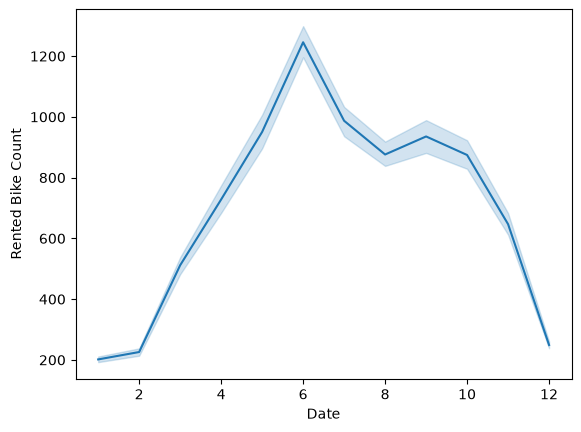

In [99]:
sns.lineplot(x = bike['Date'].dt.month, y = 'Rented Bike Count', data = bike)
# 월별 평균 렌트 개수

<Axes: xlabel='Date', ylabel='Rented Bike Count'>

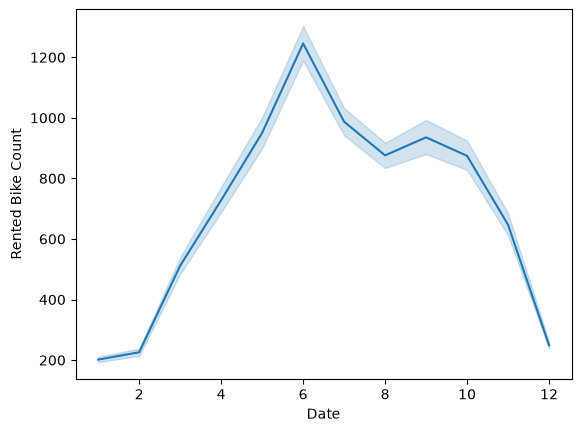

In [100]:
sns.lineplot(x = bike['Date'].dt.month, y = bike['Rented Bike Count'], data = bike)

In [101]:
#sns.lineplot(x = bike['Date'].dt.month, y = bike['Rented Bike Count'], errorbar = ('ci', {'errorbar':0}), estimator = 'sum')

In [102]:
# 종속변수 독립변수 중점으로 분석
bike.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day', 'Week', 'Day off'],
      dtype='str')

In [103]:
bike['Day off'].value_counts() / 24

# 118일 쉬었음을 알 수 있다.

Day off
No     247.0
Yes    118.0
Name: count, dtype: float64

<Axes: xlabel='Day off', ylabel='Rented Bike Count'>

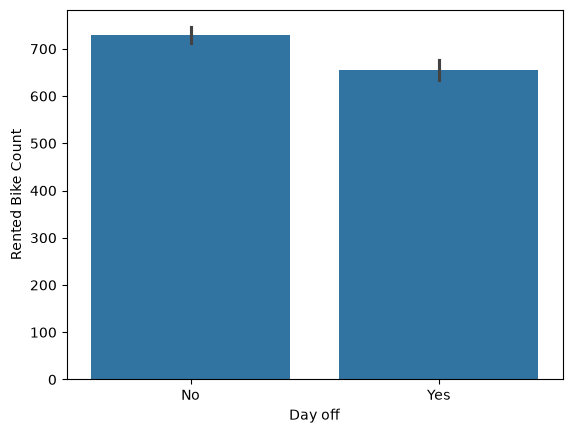

In [104]:
bike['Day off'].value_counts()
sns.barplot(x = 'Day off', y = 'Rented Bike Count', data = bike)

<Axes: xlabel='Holiday', ylabel='Rented Bike Count'>

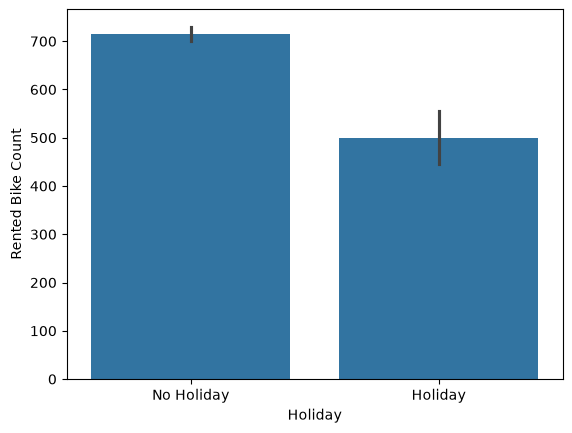

In [105]:
bike['Day off'].value_counts()
sns.barplot(x = 'Holiday', y = 'Rented Bike Count', data = bike)

#

<Axes: xlabel='Week', ylabel='Rented Bike Count'>

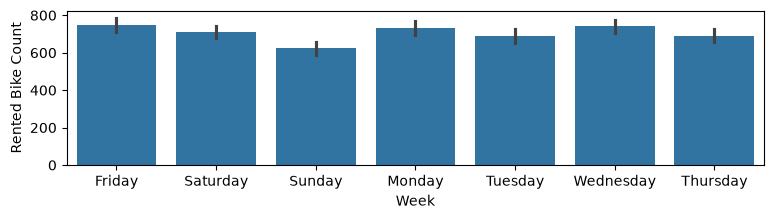

In [106]:
bike['Day off'].value_counts()

plt.figure(figsize = (9, 2))
sns.barplot(x = 'Week', y = 'Rented Bike Count', data = bike)

In [107]:
bike.corr(numeric_only= True)

# Dew point Temperature(C)와 Temperature(C) 사이의 값이 매우 높게 나옴
# 즉 같은(유사한) 데이터라고 봐도 무방하다.
# 따라서 이 두 값 모두 필요하진 않다.

# 

,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
Rented Bike Count,1.000000,0.410257,0.538558,-0.199780,0.121108,0.199280,0.379788,0.261837,-0.123074,-0.141804
Hour,0.410257,1.000000,0.124114,-0.241644,0.285197,0.098753,0.003054,0.145131,0.008715,-0.021516
Temperature(C),0.538558,0.124114,1.000000,0.159371,-0.036252,0.034794,0.912798,0.353505,0.050282,-0.218405
Humidity(%),-0.199780,-0.241644,0.159371,1.000000,-0.336683,-0.543090,0.536894,-0.461919,0.236397,0.108183
Wind speed (m/s),0.121108,0.285197,-0.036252,-0.336683,1.000000,0.171507,-0.176486,0.332274,-0.019674,-0.003554
Visibility (10m),0.199280,0.098753,0.034794,-0.543090,0.171507,1.000000,-0.176630,0.149738,-0.167629,-0.121695
Dew point temperature(C),0.379788,0.003054,0.912798,0.536894,-0.176486,-0.176630,1.000000,0.094381,0.125597,-0.150887
Solar Radiation (MJ/m2),0.261837,0.145131,0.353505,-0.461919,0.332274,0.149738,0.094381,1.000000,-0.074290,-0.072301
Rainfall(mm),-0.123074,0.008715,0.050282,0.236397,-0.019674,-0.167629,0.125597,-0.074290,1.000000,0.008500
Snowfall (cm),-0.141804,-0.021516,-0.218405,0.108183,-0.003554,-0.121695,-0.150887,-0.072301,0.008500,1.000000


In [108]:
# 분석 이어서 할것들

# 삭제 : 날짜, 이슬점, Functioning Day, rent값이 0인 데이터, Holiday, Week

# onehot, scaler 진행

# 일반화 검증

# 모델 선택(linear, ridge, randomforest)

# 학습 / 예측 / 평가

# 성능향상(gridsearch, 전처리 다르게(시간대 범주 묶기), 다항회귀 등)

<Axes: xlabel='Hour', ylabel='Rented Bike Count'>

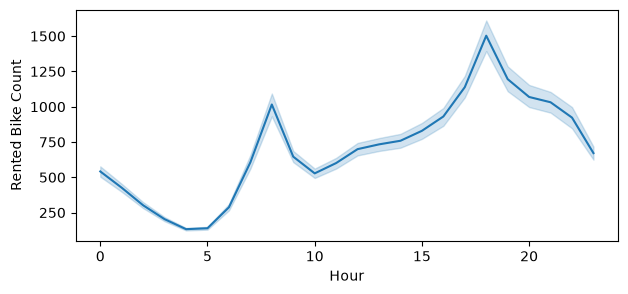

In [109]:
plt.figure(figsize = (7, 3))
sns.lineplot(x = 'Hour', y = 'Rented Bike Count', data = bike)

In [110]:
bike.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day', 'Week', 'Day off'],
      dtype='str')

<Axes: xlabel='Seasons', ylabel='Rented Bike Count'>

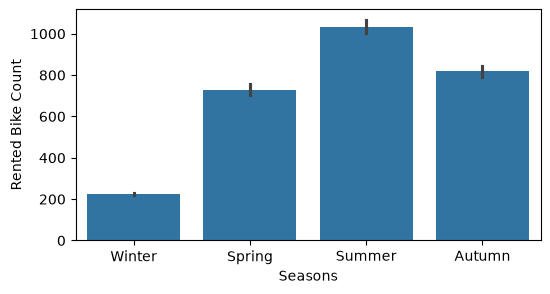

In [111]:
plt.figure(figsize = (6, 3))
sns.barplot(x = 'Seasons', y = 'Rented Bike Count', data = bike)

In [112]:
# 삭제 : 날짜, 이슬점, Functioning Day, rent값이 0인 데이터, Holiday, Week

bike = bike[bike['Rented Bike Count'] > 0]

X = bike.drop(['Date', 'Dew point temperature(C)', 'Functioning Day', 'Week', 'Rented Bike Count', 'Holiday'], axis = 1)

y = bike['Rented Bike Count']

In [113]:
X.columns

Index(['Hour', 'Temperature(C)', 'Humidity(%)', 'Wind speed (m/s)',
       'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
       'Snowfall (cm)', 'Seasons', 'Day off'],
      dtype='str')

In [114]:
X.dtypes

Hour                         int64
Temperature(C)             float64
Humidity(%)                  int64
Wind speed (m/s)           float64
Visibility (10m)             int64
Solar Radiation (MJ/m2)    float64
Rainfall(mm)               float64
Snowfall (cm)              float64
Seasons                        str
Day off                        str
dtype: object

In [115]:
# OneHot, Scaler
# from sklearn.preprocessing import OneHotEncoder, StandardScaler

oh_enc = OneHotEncoder(sparse_output = False)
oh_res = oh_enc.fit_transform(X[['Hour', 'Seasons', 'Day off']])
oh_X = pd.DataFrame(oh_res, columns = oh_enc.get_feature_names_out())

st_scaler = StandardScaler()
num_col = ['Temperature(C)', 'Humidity(%)', 'Wind speed (m/s)',
       'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
       'Snowfall (cm)']

sc_res = st_scaler.fit_transform(X[num_col])
sc_X = pd.DataFrame(sc_res, columns = num_col)

X_scaled = pd.concat([sc_X, oh_X], axis = 1)

In [116]:
# from sklearn.model_selection import cross_val_score
# from sklearn.tree import DecisionTreeRegressor

dt_reg = DecisionTreeRegressor()
cross_val_score(dt_reg, X_scaled, y, scoring = 'neg_mean_squared_error', cv = 10)

array([ -15619.61038961,   -8540.89256198,  -46517.83825266,
       -113921.36127509, -192961.25855962, -144425.06619385,
        -92456.4929078 , -118629.70449173, -121226.49527187,
       -134818.70685579])

In [117]:
# from sklearn.model_selection import cross_val_score
# from sklearn.tree import DecisionTreeRegressor

# shuffle 방법
X_rand = X_scaled.sample(frac = 1, random_state = 0)
y_rand = y.sample(frac = 1, random_state = 0)

dt_reg = DecisionTreeRegressor()
cross_val_score(dt_reg, X_rand, y_rand, scoring = 'neg_mean_squared_error', cv = 5)

array([-77039.40224454, -75074.8222091 , -67549.0472534 , -72242.49202599,
       -70957.003544  ])

In [118]:
# 모델 선택(linear, ridge, randomforest)

# 학습 / 예측 / 평가

# 성능향상(gridsearch, 전처리 다르게(시간대 범주 묶기), 다항회귀 등)

In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 0)

print(X_train.shape, X_test.shape, y_train.shape)

(6772, 37) (1693, 37) (6772,)


In [120]:
# 학습 / 예측 / 평가
# 성능향상(gridsearch, 전처리 다르게(시간대 범주 묶기), 다항회귀 등)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
pred = lr_reg.predict(X_test)
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

378.58069260427027
0.6353286302424679


In [121]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha = 0.1)
ridge.fit(X_train, y_train)
pred = ridge.predict(X_test)
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

378.57177010860147
0.6353458193936199


In [122]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor()
rf_reg.fit(X_train, y_train)
pred = rf_reg.predict(X_test)
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

209.11215908262267
0.8887389080967205


In [123]:
# 성능향상(gridsearch, 전처리 다르게(시간대 범주 묶기), 다항회귀 등)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=200)
parameters = {'max_depth' : [None, 3, 5, 7],
              'min_samples_split' : [2, 5, 9],
              'min_samples_leaf' : [1, 5, 10],
              'random_state' : [0]
              }
grid = GridSearchCV(rf_reg, param_grid=parameters, scoring ='neg_root_mean_squared_error', cv = 5, n_jobs=-1)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...stimators=200)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 5, ...], 'random_state': [0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable 

In [124]:
grid.best_params_  

{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'random_state': 0}

In [125]:
model = grid.best_estimator_
pred = model.predict(X_test)
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

208.35536166780207
0.8895427804229361


In [126]:
st_scaler.mean_
# 

array([1.27710573e+01, 5.81471943e+01, 1.72588305e+00, 1.43387348e+03,
       5.67867690e-01, 1.49119905e-01, 7.76845836e-02])

In [127]:
# X_train, X_test를 다항회귀 > linear, ridge

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree = 2, include_bias = False)
poly.fit(X_train)
X_train_poly = poly.transform(X_train)
X_test_poly = poly.transform(X_test)
print(X_train_poly.shape)

(6772, 740)


In [128]:
lr_reg = LinearRegression()
lr_reg.fit(X_train_poly, y_train)
pred = lr_reg.predict(X_test_poly)
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

246.0724471901792
0.8459326111591141


In [129]:
# X_train, X_test를 다항회귀 > linear, ridge

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree = 3, include_bias = False)
poly.fit(X_train)
X_train_poly = poly.transform(X_train)
X_test_poly = poly.transform(X_test)
print(X_train_poly.shape)

(6772, 9879)


In [130]:
lr_reg = LinearRegression()
lr_reg.fit(X_train_poly, y_train)
pred = lr_reg.predict(X_test_poly)
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

2193.1023377261986
-11.237777169747707


In [131]:
ridge = Ridge(alpha=5)
ridge.fit(X_train_poly, y_train)
pred = ridge.predict(X_test_poly)
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

311.20819373097277
0.7535738503801099


In [132]:
# 2차 poly 데이터
poly = PolynomialFeatures(degree = 2, include_bias = False)
poly.fit(X_train)
X_train_poly = poly.transform(X_train)
X_test_poly = poly.transform(X_test)

ridge = Ridge(alpha=10)
ridge.fit(X_train_poly, y_train)
pred = ridge.predict(X_test_poly)
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

241.86746542132963
0.8511531485032287


In [133]:
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

In [134]:
col = X.columns

In [135]:
X.iloc[200]

Hour                            8
Temperature(C)               -5.4
Humidity(%)                    56
Wind speed (m/s)              0.7
Visibility (10m)             1940
Solar Radiation (MJ/m2)      0.01
Rainfall(mm)                  0.0
Snowfall (cm)                 0.0
Seasons                    Winter
Day off                       Yes
Name: 200, dtype: object

In [136]:
hour = 8 # int(input('시간대 : '))
temp = -5.4 # float(input('온도 : '))
humid = 56 # int(input('습도 : '))
wind = 0.7 # float(input('풍속 : '))
visi = 1940 # int(input('가시거리(10m) : '))
solar = 0.01 # float(input('태양열 : '))
rain = 0.0 # float(input('강수량 : '))
snow = 0.0 # float(input('적설량 : '))
season = 'Winter' # input('계절(Winter/Autumn/Spring/Summer) : ')
day = 'Yes' # input('주말여부(Yes/No) : ')

pred_data = pd.DataFrame([[hour, temp, humid, wind, visi, 
                          solar, rain, snow, season, day]], columns = col)

pred_oh = oh_enc.transform(pred_data[['Hour', 'Seasons', 'Day off']])
oh_pred = pd.DataFrame(pred_oh, columns= oh_enc.get_feature_names_out() )

pred_sc = st_scaler.transform(pred_data[num_col])
sc_pred = pd.DataFrame(pred_sc, columns = num_col)

pred_data = pd.concat([sc_pred, oh_pred], axis = 1)

In [137]:
model.predict(pred_data), y.iloc[200]

(array([114.84]), np.int64(222))